# Handedness — Frontal Alpha Asymmetry (LAT-1..4)


# HANDENESS

## LAT-1: Frontal Alpha Asymmetry (FAA) by handedness

### What is FAA?

Frontal Alpha Asymmetry measures the balance of alpha power between left and right frontal electrodes:

**FAA = ln(alpha_right) − ln(alpha_left)**

Since alpha power is *inversely* related to cortical activation (more alpha = less active), a positive FAA means relatively greater left-hemisphere activation, and vice versa.

### Hypothesis

Right-handers typically show left-hemisphere motor dominance, which may be reflected in FAA. Left-handers are hypothesised to show reduced or reversed asymmetry — or, according to more recent literature, simply **greater variability** in hemispheric organisation.

### Method

- Computed on **REC (eyes closed)** — strongest, cleanest alpha signal
- **4 frontal electrode pairs** available on the Emotiv Epoc: AF3↔AF4, F7↔F8, F3↔F4, FC5↔FC6
- Statistical comparison: **Mann-Whitney U test** (non-parametric, appropriate given the small left-handed group)
- **Important limitation**: only 5 left-handers out of 49 subjects — results are exploratory

### Known statistical limitation

With n = 5 in the left-handed group, the test has very low statistical power. A true medium-sized effect (d ≈ 0.5) would require ~30 subjects per group to detect reliably. Results should be interpreted as descriptive patterns, not confirmatory findings.

Computing frontal alpha asymmetry...
  49 subjects

=== Group sizes ===
  Right       : 42
  Left        : 5
  Ambidextrous: 2

=== Frontal Alpha Asymmetry: Right vs Left handers ===
  (FAA > 0 = relative left-hemisphere dominance)

  Pair             Right mean   Left mean    U p-val
  --------------------------------------------------
  AF3↔AF4              +0.076      +0.289      0.557
  F7↔F8                +0.011      +0.409      0.119
  F3↔F4                -0.151      +0.078      0.627
  FC5↔FC6              -0.112      -0.008      0.603
  mean                 -0.044      +0.192      0.119


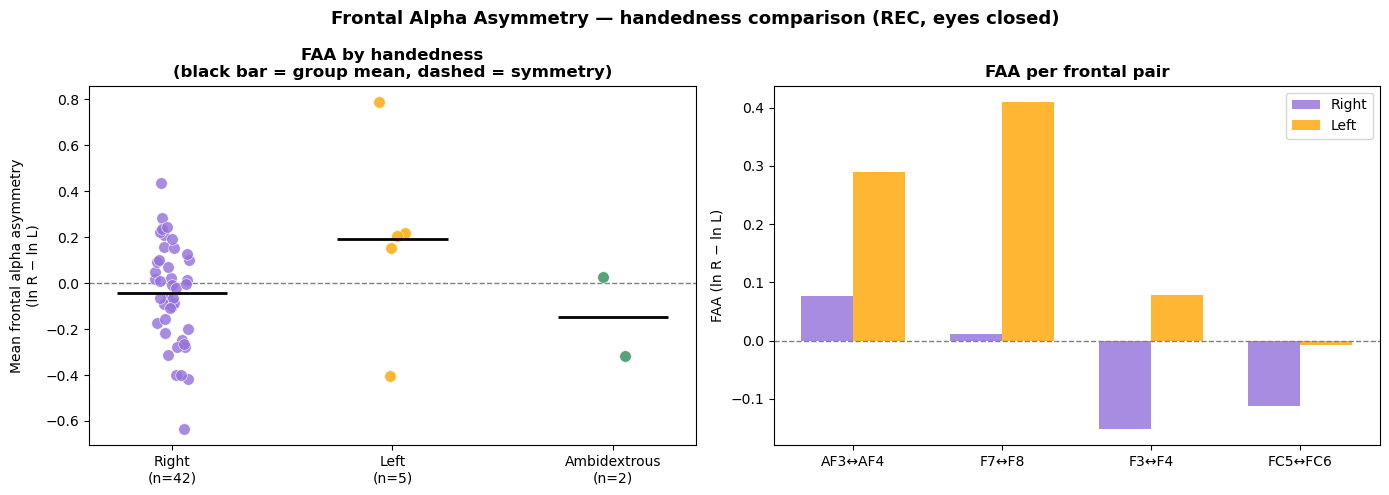

In [17]:
# ============================================================
# CELL LAT-1: Frontal Alpha Asymmetry (FAA) by handedness
#
# FAA = ln(alpha_power_right) - ln(alpha_power_left)
#   computed for homologous frontal electrode pairs.
#
# Interpretation (alpha is INVERSELY related to activation):
#   FAA > 0  → more alpha on right → LESS right activation
#              → relative LEFT-hemisphere dominance (typical R-handers)
#   FAA < 0  → relative right-hemisphere dominance
#
# Hypothesis: left-handers show reduced or reversed FAA
#             (less lateralised organisation).
#
# Frontal pairs available on Emotiv (left → right):
#   AF3↔AF4, F7↔F8, F3↔F4, FC5↔FC6
#
# Computed on REC (eyes closed) — strongest, cleanest alpha.
# Statistical test: Mann-Whitney U (non-parametric, robust to
# the tiny left-handed group). Underpowered — exploratory only.
# ============================================================

from scipy.signal import welch
from scipy.stats  import mannwhitneyu

FRONTAL_PAIRS = [('AF3', 'AF4'), ('F7', 'F8'), ('F3', 'F4'), ('FC5', 'FC6')]

def alpha_power(segment, ch_name, sfreq=SFREQ):
    """Mean alpha (8-13 Hz) power for one channel."""
    idx = EEG_CHANNELS.index(ch_name)
    f, psd = welch(segment[idx], fs=sfreq, nperseg=min(256, segment.shape[1]))
    return psd[(f >= 8) & (f < 13)].mean()

# ── Compute FAA per subject ───────────────────────────────────────
print("Computing frontal alpha asymmetry...")
rows = []
for _, row in coh_df.iterrows():
    sid = row['subject_id']
    try:
        segs = extract_condition_segments(find_edf(sid, session='G10'))
        rec  = segs.get('REC')
        if rec is None:
            continue
        rec_row = {'subject_id': sid}
        faa_vals = []
        for left, right in FRONTAL_PAIRS:
            pL = alpha_power(rec, left)
            pR = alpha_power(rec, right)
            faa = np.log(pR + 1e-12) - np.log(pL + 1e-12)
            rec_row[f'faa_{left}_{right}'] = faa
            faa_vals.append(faa)
        rec_row['faa_mean'] = np.mean(faa_vals)   # overall frontal asymmetry
        rows.append(rec_row)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

faa_df = pd.DataFrame(rows).merge(
    coh_df[['subject_id', 'age', 'sex', 'handedness']], on='subject_id')

print(f"  {len(faa_df)} subjects\n")

# ── Group comparison: Right vs Left handers ───────────────────────
right = faa_df[faa_df['handedness'] == 'Right']
left  = faa_df[faa_df['handedness'] == 'Left']
ambi  = faa_df[faa_df['handedness'] == 'Ambidextrous']

print("=== Group sizes ===")
print(f"  Right       : {len(right)}")
print(f"  Left        : {len(left)}")
print(f"  Ambidextrous: {len(ambi)}\n")

print("=== Frontal Alpha Asymmetry: Right vs Left handers ===")
print(f"  (FAA > 0 = relative left-hemisphere dominance)\n")
print(f"  {'Pair':<14s}  {'Right mean':>11s}  {'Left mean':>10s}  {'U p-val':>9s}")
print("  " + "-" * 50)

faa_cols = [f'faa_{l}_{r}' for l, r in FRONTAL_PAIRS] + ['faa_mean']
for col in faa_cols:
    rm = right[col].mean()
    lm = left[col].mean()
    try:
        _, p = mannwhitneyu(right[col], left[col], alternative='two-sided')
        p_str = f"{p:.3f}"
        flag  = '  *' if p < 0.05 else ''
    except ValueError:
        p_str, flag = 'n/a', ''
    label = col.replace('faa_', '').replace('_', '↔')
    print(f"  {label:<14s}  {rm:>+11.3f}  {lm:>+10.3f}  {p_str:>9s}{flag}")

# ── Visual: FAA mean by handedness ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: boxplot + individual points
ax = axes[0]
groups = [('Right', right, 'mediumpurple'),
          ('Left',  left,  'orange'),
          ('Ambidextrous', ambi, 'seagreen')]
for i, (name, grp, color) in enumerate(groups):
    vals = grp['faa_mean'].values
    ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.08, 0.08, len(vals)),
               vals, color=color, s=70, alpha=0.8,
               edgecolors='white', linewidth=0.5, zorder=3)
    if len(vals) > 0:
        ax.hlines(vals.mean(), i - 0.25, i + 0.25,
                  color='black', lw=2, zorder=4)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(range(3))
ax.set_xticklabels([f'{n}\n(n={len(g)})' for n, g, _ in groups])
ax.set_ylabel('Mean frontal alpha asymmetry\n(ln R − ln L)')
ax.set_title('FAA by handedness\n(black bar = group mean, dashed = symmetry)',
             fontweight='bold')

# Panel 2: FAA per pair, Right vs Left
ax = axes[1]
x = np.arange(len(FRONTAL_PAIRS))
width = 0.35
r_means = [right[f'faa_{l}_{rr}'].mean() for l, rr in FRONTAL_PAIRS]
l_means = [left[f'faa_{l}_{rr}'].mean()  for l, rr in FRONTAL_PAIRS]
ax.bar(x - width/2, r_means, width, label='Right', color='mediumpurple', alpha=0.8)
ax.bar(x + width/2, l_means, width, label='Left',  color='orange', alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f'{l}↔{rr}' for l, rr in FRONTAL_PAIRS])
ax.set_ylabel('FAA (ln R − ln L)')
ax.set_title('FAA per frontal pair', fontweight='bold')
ax.legend()

plt.suptitle('Frontal Alpha Asymmetry — handedness comparison (REC, eyes closed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### LAT-1 Results: No significant mean difference, but suggestive variability pattern

| Pair | Right-handers (n=42) | Left-handers (n=5) | p (Mann-Whitney) |
|------|---------------------|-------------------|-------------------|
| AF3↔AF4 | +0.076 | +0.289 | 0.557 |
| F7↔F8 | +0.011 | +0.409 | 0.119 |
| F3↔F4 | −0.151 | +0.078 | 0.627 |
| FC5↔FC6 | −0.112 | −0.008 | 0.603 |
| **Mean FAA** | **−0.044** | **+0.192** | **0.119** |

**No significant differences** in mean FAA between groups (all p > 0.05).

However, the scatter plot reveals a more interesting pattern: the 5 left-handers are **widely dispersed** (range: −0.40 to +0.79), while the 42 right-handers are more concentrated around zero (range: −0.63 to +0.44 but with most values between −0.3 and +0.2). This suggests that left-handers may not differ in *average* lateralisation, but in the *variability* of their hemispheric organisation — consistent with the behavioural literature. This is tested formally in LAT-2.

## LAT-2: Is FAA more *variable* in left-handers?

### Shifting the question: from mean to spread

LAT-1 showed no significant difference in **mean** FAA between handedness groups. But the scatter plot suggested a different pattern: left-handers appear more **spread out** than right-handers.

This aligns with the modern view of handedness in neuroscience: left-handers are not simply "reversed" right-handers — they are a **heterogeneous group** with diverse hemispheric organisation patterns. Some have typical (left-dominant) organisation, others have atypical or reversed patterns.

### Method

- **Levene's test**: compares the variance of FAA between groups (robust to non-normality)
- **SD ratio**: descriptive measure — standard deviation of left-handers divided by that of right-handers
- If SD ratio > 1 and Levene is significant → left-handers are genuinely more variable

In [18]:
# ============================================================
# CELL LAT-2: Test FAA *variability* (not mean) by handedness
#
# The boxplot suggests left-handers are more SPREAD OUT in FAA,
# not shifted in mean. Behavioural literature supports this:
# left-handers are more heterogeneous in hemispheric organisation.
#
# Levene's test compares variances between groups (robust to
# non-normality). This is the right question given the data.
# ============================================================

from scipy.stats import levene

r_faa = right['faa_mean'].values
l_faa = left['faa_mean'].values

print("=== FAA spread (variability) by handedness ===\n")
print(f"  {'Group':<14s}  {'n':>3s}  {'mean':>8s}  {'std':>7s}  {'range':>16s}")
print("  " + "-" * 56)
for name, vals in [('Right', r_faa), ('Left', l_faa)]:
    print(f"  {name:<14s}  {len(vals):>3d}  {vals.mean():>+8.3f}  "
          f"{vals.std():>7.3f}  [{vals.min():+.2f}, {vals.max():+.2f}]")

# Levene's test for equality of variances
stat, p_lev = levene(r_faa, l_faa)
print(f"\n  Levene's test (equal variances?):")
print(f"    statistic = {stat:.3f},  p = {p_lev:.3f}")
print(f"    → left-handers {'ARE' if p_lev < 0.05 else 'are NOT'} "
      f"significantly more variable (α=0.05)")

# Ratio of standard deviations as effect size
sd_ratio = l_faa.std() / r_faa.std()
print(f"\n  SD ratio (Left/Right): {sd_ratio:.2f}x")
print(f"    (left-handers' FAA spread is {sd_ratio:.1f}× that of right-handers)")

=== FAA spread (variability) by handedness ===

  Group             n      mean      std             range
  --------------------------------------------------------
  Right            42    -0.044    0.219  [-0.63, +0.44]
  Left              5    +0.192    0.378  [-0.40, +0.79]

  Levene's test (equal variances?):
    statistic = 1.022,  p = 0.317
    → left-handers are NOT significantly more variable (α=0.05)

  SD ratio (Left/Right): 1.73x
    (left-handers' FAA spread is 1.7× that of right-handers)


### LAT-2 Results: Suggestive variability difference, underpowered

| Group | n | Mean FAA | Std | Range |
|-------|---|----------|-----|-------|
| Right-handers | 42 | −0.044 | 0.219 | [−0.63, +0.44] |
| Left-handers | 5 | +0.192 | 0.378 | [−0.40, +0.79] |

- **Levene's test**: p = 0.317 (not significant)
- **SD ratio**: 1.73× (left-handers' FAA spread is 1.7 times that of right-handers)

The variability pattern goes in the expected direction — left-handers are more dispersed — but the test lacks statistical power with only 5 left-handed subjects. This is a known limitation: Levene's test requires roughly 20+ subjects per group to detect a variance ratio of ~2× reliably.

### Conclusion on handedness/laterality

Left-handers showed a non-significant trend towards both higher mean FAA (+0.192 vs −0.044) and greater variability (SD ratio 1.73×). The variability pattern is consistent with the well-documented heterogeneity of hemispheric organisation in left-handers, but the sample (n = 5) lacks the statistical power to confirm either effect. A dataset with ≥20 left-handers would be needed for conclusive analysis.

This closes the laterality analysis. The limitation is not methodological but sample-driven — the same analysis pipeline would yield interpretable results with a more balanced sample.

## LAT-3 & LAT-4: Epoch-level FAA and multi-condition analysis

### Going beyond the single subject-level average

- **LAT-3** (REC only): split the 10-second rest segment into 2-second epochs and compute FAA per epoch — features are mean, std and skewness of that distribution.
- **LAT-4** (all conditions): compute epoch-level FAA on REC, REO and TASK, then measure delta_FAA = TASK_mean - REC_mean as the *task-induced lateralization shift*.

`epoch_faa_dist()` is defined in LAT-3; run LAT-3 before LAT-4.

In [10]:
# ============================================================
# CELL LAT-3: Epoch-level FAA — beyond the single-subject mean
#
# LAT-1 computed one FAA value per subject (mean over entire REC).
# Here: split each segment into 2-second epochs (50% overlap),
# compute FAA per epoch, then extract distribution features:
#   - mean  : replicates LAT-1 (sanity check)
#   - std   : within-subject temporal variability of lateralization
#   - skew  : directional bias of FAA fluctuations over time
#
# Hypothesis: left-handers may not differ in *mean* FAA but in
# how much their hemispheric lateralization fluctuates over time.
# ============================================================

from scipy.stats import mannwhitneyu, skew as scipy_skew
from scipy.signal import welch

EPOCH_DUR  = 2.0
EPOCH_SAMP = int(EPOCH_DUR * SFREQ)   # 256 samples at 128 Hz
STEP       = EPOCH_SAMP // 2          # 50% overlap

FRONTAL_PAIRS = [('AF3', 'AF4'), ('F7', 'F8'), ('F3', 'F4'), ('FC5', 'FC6')]


def alpha_power_arr(data, ch_name, sfreq=SFREQ):
    """Mean alpha (8-13 Hz) power for one channel from a data array (14, n)."""
    idx = EEG_CHANNELS.index(ch_name)
    f, psd = welch(data[idx], fs=sfreq, nperseg=min(256, data.shape[1]))
    return psd[(f >= 8) & (f < 13)].mean()


def epoch_faa_dist(segment, pairs=FRONTAL_PAIRS, sfreq=SFREQ):
    """
    Split segment into 2-second epochs (50% overlap) and compute FAA per epoch.
    Returns dict: 'L_R' -> np.array of per-epoch FAA values.
    """
    n = segment.shape[1]
    faa_by_pair = {f'{l}_{r}': [] for l, r in pairs}
    start = 0
    while start + EPOCH_SAMP <= n:
        epoch = segment[:, start:start + EPOCH_SAMP]
        for l, r in pairs:
            pL = alpha_power_arr(epoch, l, sfreq)
            pR = alpha_power_arr(epoch, r, sfreq)
            faa_by_pair[f'{l}_{r}'].append(np.log(pR + 1e-12) - np.log(pL + 1e-12))
        start += STEP
    return {k: np.array(v) for k, v in faa_by_pair.items()}


# -- Build epoch-FAA feature matrix -------------------------------------------
print("Computing epoch-level FAA for all subjects (REC condition)...")
lat3_rows = []
for _, row in coh_df.iterrows():
    sid = row['subject_id']
    try:
        segs = extract_condition_segments(find_edf(sid, session='G10'))
        rec  = segs.get('REC')
        if rec is None or rec.shape[1] < EPOCH_SAMP:
            continue
        dist  = epoch_faa_dist(rec)
        feat  = {'subject_id': sid}
        all_v = []
        for pair_key, vals in dist.items():
            feat[f'faa_{pair_key}_mean'] = vals.mean()
            feat[f'faa_{pair_key}_std']  = vals.std()
            feat[f'faa_{pair_key}_skew'] = scipy_skew(vals) if len(vals) >= 3 else 0.0
            all_v.append(vals)
        flat = np.concatenate(all_v)
        feat['faa_global_mean'] = flat.mean()
        feat['faa_global_std']  = flat.std()
        feat['faa_global_skew'] = scipy_skew(flat)
        lat3_rows.append(feat)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

lat3_df = pd.DataFrame(lat3_rows).merge(
    coh_df[['subject_id', 'age', 'sex', 'handedness']], on='subject_id')

right3 = lat3_df[lat3_df['handedness'] == 'Right']
left3  = lat3_df[lat3_df['handedness'] == 'Left']
print(f"  {len(lat3_df)} subjects  |  Right: {len(right3)}  Left: {len(left3)}\n")

# -- Compare distribution features Right vs Left ------------------------------
feat_cols = [c for c in lat3_df.columns if c.startswith('faa_')]
print("=== Epoch-level FAA features: Right vs Left handers (REC) ===")
print(f"  {'Feature':<30s}  {'Right mean':>11s}  {'Left mean':>10s}  {'p (MW)':>8s}")
print("  " + "-" * 66)
for col in feat_cols:
    r_v = right3[col].dropna()
    l_v = left3[col].dropna()
    try:
        _, p = mannwhitneyu(r_v, l_v, alternative='two-sided')
        flag  = '  *' if p < 0.05 else ''
        p_str = f'{p:.3f}'
    except Exception:
        flag, p_str = '', 'n/a'
    print(f"  {col.replace('faa_', ''):<30s}  {r_v.mean():>+11.3f}  {l_v.mean():>+10.3f}  {p_str:>8s}{flag}")

Computing epoch-level FAA for all subjects (REC condition)...
  49 subjects  |  Right: 42  Left: 5

=== Epoch-level FAA features: Right vs Left handers (REC) ===
  Feature                          Right mean   Left mean    p (MW)
  ------------------------------------------------------------------
  AF3_AF4_mean                         +0.078      +0.159     0.854
  AF3_AF4_std                          +0.349      +0.407     0.449
  AF3_AF4_skew                         +0.173      +0.626     0.157
  F7_F8_mean                           +0.017      +0.328     0.137
  F7_F8_std                            +0.389      +0.482     0.319
  F7_F8_skew                           -0.054      +0.176     0.336
  F3_F4_mean                           -0.134      +0.010     0.557
  F3_F4_std                            +0.241      +0.374     0.058
  F3_F4_skew                           +0.061      -0.068     0.802
  FC5_FC6_mean                         -0.101      -0.025     0.776
  FC5_FC6_std        

Computing epoch-level FAA for REC, REO and TASK...

=== FAA per condition: Right vs Left handers ===
  Measure                        Right (n=42)   Left (n=5)    p (MW)
  --------------------------------------------------------------------
  REC  — mean FAA                      -0.035       +0.118     0.256
  REO  — mean FAA                      +0.002       +0.023     0.535
  TASK — mean FAA                      -0.005       +0.128     0.491
  delta_FAA  TASK-REC                  +0.030       +0.010     0.802
  delta_FAA  REO-REC                   +0.037       -0.096     0.069
  REC  — temporal std                  +0.477       +0.556     0.303
  REO  — temporal std                  +0.461       +0.465     0.700
  TASK — temporal std                  +0.499       +0.535     0.880


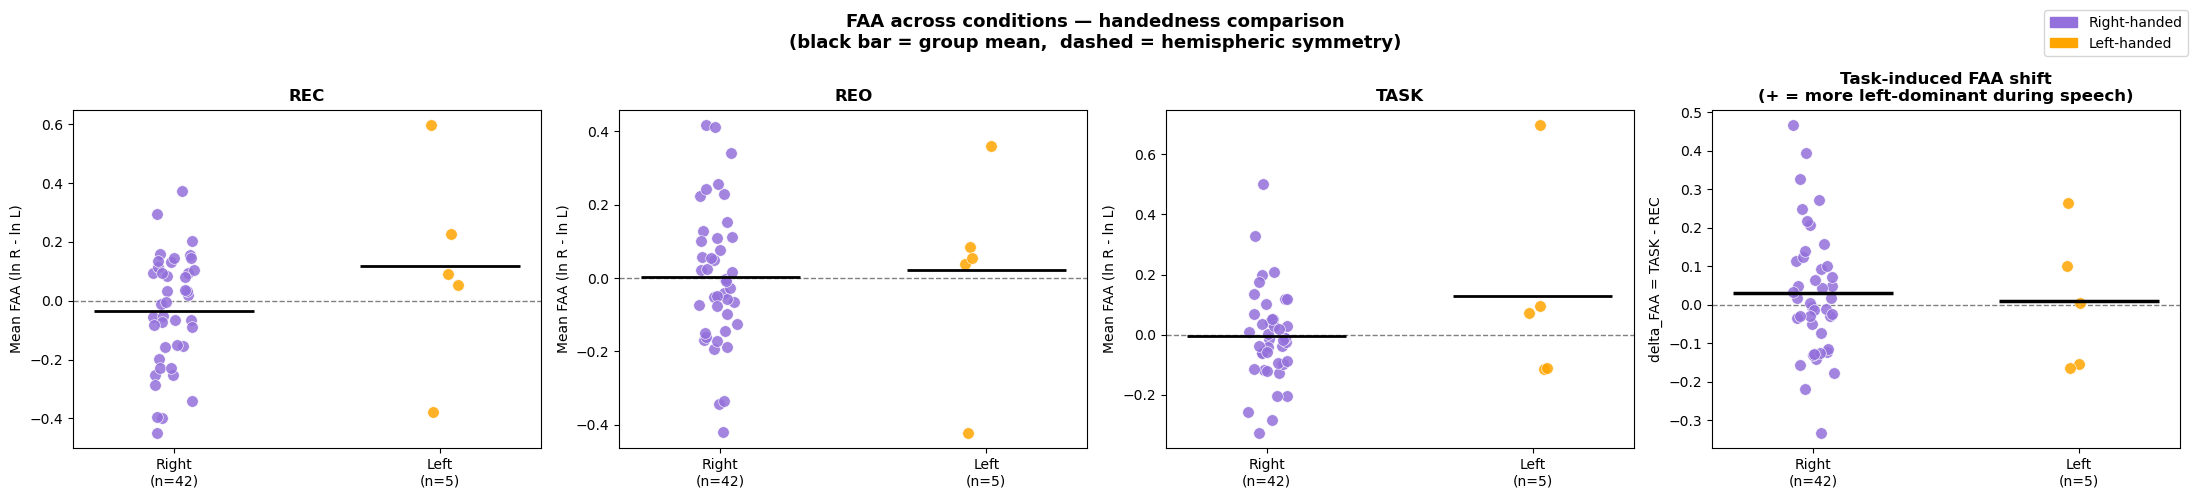

In [11]:
# ============================================================
# CELL LAT-4: FAA across conditions — REC, REO and TASK
#
# Speech production (TASK) is strongly left-lateralised:
#   left hemisphere activates → alpha decreases on the left
#   → FAA = ln(R) − ln(L) should RISE during TASK vs REC
#
# Key measure: delta_FAA = TASK_mean − REC_mean per subject.
#   If left-handers are less left-lateralised for speech,
#   their delta_FAA should be SMALLER or reversed.
#
# REO vs REC serves as a control: eye-opening without any
# motor speech activation → smaller or null shift expected.
# ============================================================

print("Computing epoch-level FAA for REC, REO and TASK...")
lat4_rows = []
for _, row in coh_df.iterrows():
    sid = row['subject_id']
    try:
        segs = extract_condition_segments(find_edf(sid, session='G10'))
        feat = {'subject_id': sid}
        for cond in ['REC', 'REO', 'TASK']:
            seg = segs.get(cond)
            if seg is None or seg.shape[1] < EPOCH_SAMP:
                feat[f'faa_mean_{cond}'] = np.nan
                feat[f'faa_std_{cond}']  = np.nan
                continue
            dist  = epoch_faa_dist(seg)
            flat  = np.concatenate(list(dist.values()))
            feat[f'faa_mean_{cond}'] = flat.mean()
            feat[f'faa_std_{cond}']  = flat.std()
        lat4_rows.append(feat)
    except Exception as e:
        print(f"  {sid}: ERROR {e}")

lat4_df = pd.DataFrame(lat4_rows).merge(
    coh_df[['subject_id', 'age', 'sex', 'handedness']], on='subject_id')

lat4_df['delta_task_rec'] = lat4_df['faa_mean_TASK'] - lat4_df['faa_mean_REC']
lat4_df['delta_reo_rec']  = lat4_df['faa_mean_REO']  - lat4_df['faa_mean_REC']

right4 = lat4_df[lat4_df['handedness'] == 'Right']
left4  = lat4_df[lat4_df['handedness'] == 'Left']

# -- Summary table ------------------------------------------------------------
compare_cols = [
    ('REC  — mean FAA',      'faa_mean_REC'),
    ('REO  — mean FAA',      'faa_mean_REO'),
    ('TASK — mean FAA',      'faa_mean_TASK'),
    ('delta_FAA  TASK-REC',  'delta_task_rec'),
    ('delta_FAA  REO-REC',   'delta_reo_rec'),
    ('REC  — temporal std',  'faa_std_REC'),
    ('REO  — temporal std',  'faa_std_REO'),
    ('TASK — temporal std',  'faa_std_TASK'),
]

print("\n=== FAA per condition: Right vs Left handers ===")
print(f"  {'Measure':<28s}  {'Right (n=42)':>13s}  {'Left (n=5)':>11s}  {'p (MW)':>8s}")
print("  " + "-" * 68)
for label, col in compare_cols:
    r_v = right4[col].dropna()
    l_v = left4[col].dropna()
    try:
        _, p = mannwhitneyu(r_v, l_v, alternative='two-sided')
        flag  = '  *' if p < 0.05 else ''
        p_str = f'{p:.3f}'
    except Exception:
        flag, p_str = '', 'n/a'
    print(f"  {label:<28s}  {r_v.mean():>+13.3f}  {l_v.mean():>+11.3f}  {p_str:>8s}{flag}")

# -- Visualisation ------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
conditions4 = ['REC', 'REO', 'TASK']
groups4     = [('Right', right4, 'mediumpurple'),
               ('Left',  left4,  'orange')]

for ax, cond in zip(axes[:3], conditions4):
    col = f'faa_mean_{cond}'
    for i, (name, grp, color) in enumerate(groups4):
        vals   = grp[col].dropna().values
        jitter = np.random.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, s=70, alpha=0.85,
                   edgecolors='white', linewidth=0.5, zorder=3)
        if len(vals):
            ax.hlines(vals.mean(), i - 0.3, i + 0.3,
                      color='black', lw=2, zorder=4)
    ax.axhline(0, color='gray', linestyle='--', lw=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{n}\n(n={len(grp[col].dropna())})'
                        for n, grp, _ in groups4])
    ax.set_ylabel('Mean FAA (ln R - ln L)')
    ax.set_title(f'{cond}', fontweight='bold')

# Panel 4: delta_FAA = TASK - REC
ax = axes[3]
col = 'delta_task_rec'
for i, (name, grp, color) in enumerate(groups4):
    vals   = grp[col].dropna().values
    jitter = np.random.uniform(-0.08, 0.08, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color=color, s=70, alpha=0.85,
               edgecolors='white', linewidth=0.5, zorder=3)
    if len(vals):
        ax.hlines(vals.mean(), i - 0.3, i + 0.3,
                  color='black', lw=2.5, zorder=4)
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xticks([0, 1])
ax.set_xticklabels([f'{n}\n(n={len(grp[col].dropna())})'
                    for n, grp, _ in groups4])
ax.set_ylabel('delta_FAA = TASK - REC')
ax.set_title('Task-induced FAA shift\n'
             '(+ = more left-dominant during speech)', fontweight='bold')

patches = [mpatches.Patch(color='mediumpurple', label='Right-handed'),
           mpatches.Patch(color='orange',       label='Left-handed')]
fig.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.suptitle('FAA across conditions — handedness comparison\n'
             '(black bar = group mean,  dashed = hemispheric symmetry)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Building epoch-level dataframe...
  Total epoch observations: 14892

  Epochs per condition and group:
condition  handedness
REC        Left             45
           Right           378
REO        Left             45
           Right           378
TASK       Left           1493
           Right         12553


=== Linear Mixed Effects: faa ~ C(handedness) + (1|subject) ===
  Referencia: Right-handers.  beta_Left = Left FAA - Right FAA

  Cond     beta_Left        SE        z           p  CI 95%
  -----------------------------------------------------------------
  REC         -0.118       nan      nan         nan  [+nan, +nan]
  REO         -0.066       nan      nan         nan  [+nan, +nan]
  TASK        +0.133     0.084     1.58      0.1149  [-0.032, +0.298]


=== Permutation test (2000 perm., etiquetas permutadas entre sujetos) ===
  Estadístico: mean_FAA_Left - mean_FAA_Right (medias por sujeto)

  Cond     Observed diff     p_perm      p_LME
  -------------------------------------

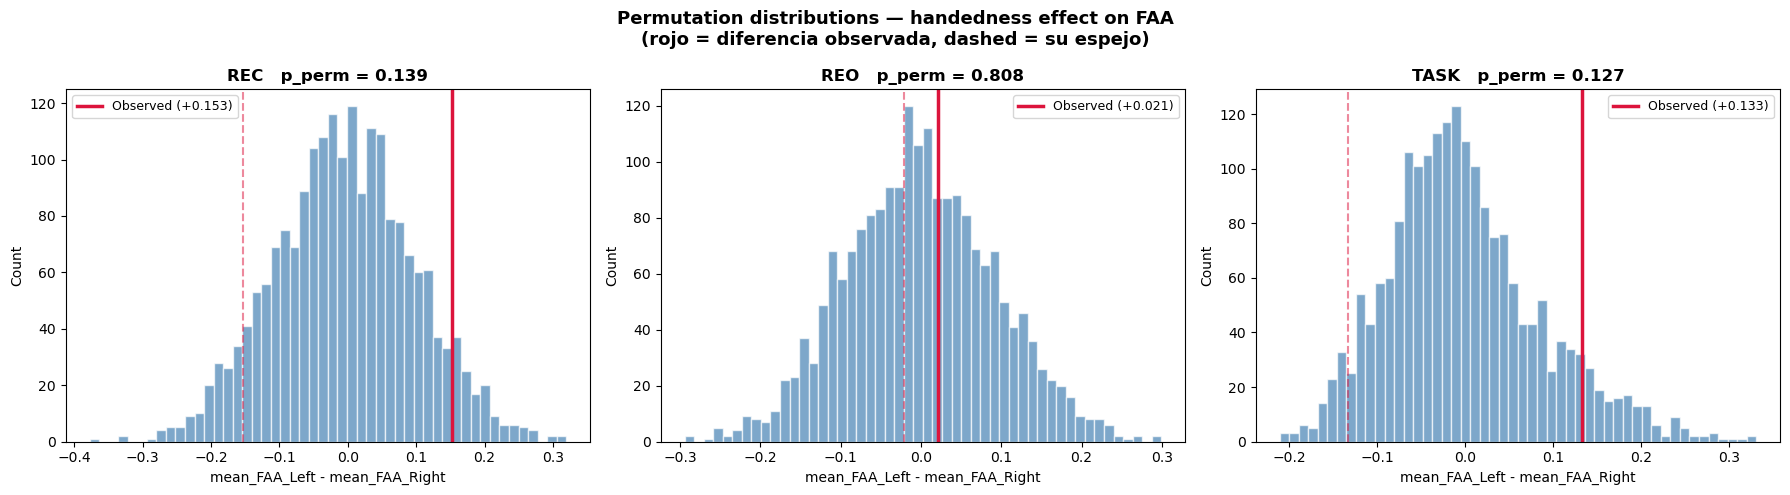

In [12]:
  # ============================================================
  # CELL LAT-5: Linear Mixed Effects Model + Permutation Test
  #
  # Model: faa_epoch ~ C(handedness) + (1 | subject_id)
  #   - Fixed effect: handedness (Right vs Left)
  #   - Random intercept per subject
  #   - Cada EPOCH es una observación — sin promediar dentro del sujeto
  #
  # Requiere LAT-3 ejecutado antes (epoch_faa_dist, EPOCH_SAMP, etc.)
  # ============================================================

  from statsmodels.formula.api import mixedlm
  import warnings
  warnings.filterwarnings('ignore')

  # -- 1. Dataframe a nivel de epoch (una fila por epoch) -----------------------
  print("Building epoch-level dataframe...")
  epoch_rows = []
  for _, row in coh_df.iterrows():
      sid  = row['subject_id']
      hand = row['handedness']
      if hand == 'Ambidextrous':
          continue
      try:
          segs = extract_condition_segments(find_edf(sid, session='G10'))
          for cond in ['REC', 'REO', 'TASK']:
              seg = segs.get(cond)
              if seg is None or seg.shape[1] < EPOCH_SAMP:
                  continue
              dist = epoch_faa_dist(seg)
              n_ep = len(next(iter(dist.values())))
              for ep_idx in range(n_ep):
                  faa_ep = np.mean([vals[ep_idx] for vals in dist.values()])
                  epoch_rows.append({
                      'subject_id': sid,
                      'handedness': hand,
                      'condition':  cond,
                      'faa':        faa_ep,
                  })
      except Exception as e:
          print(f"  {sid}: ERROR {e}")

  epoch_df = pd.DataFrame(epoch_rows)
  print(f"  Total epoch observations: {len(epoch_df)}")
  print("\n  Epochs per condition and group:")
  print(epoch_df.groupby(['condition', 'handedness'])['faa'].count().to_string())

  # -- 2. LME por condición -----------------------------------------------------
  print("\n\n=== Linear Mixed Effects: faa ~ C(handedness) + (1|subject) ===")
  print("  Referencia: Right-handers.  beta_Left = Left FAA - Right FAA\n")
  print(f"  {'Cond':<6}  {'beta_Left':>10}  {'SE':>8}  {'z':>7}  {'p':>10}  CI 95%")
  print("  " + "-" * 65)

  COEF = "C(handedness, Treatment('Right'))[T.Left]"
  lme_results = {}

  for cond in ['REC', 'REO', 'TASK']:
      df_c = epoch_df[epoch_df['condition'] == cond].copy()
      if df_c['handedness'].nunique() < 2:
          print(f"  {cond:<6}  [solo un grupo — skip]")
          continue
      try:
          model  = mixedlm("faa ~ C(handedness, Treatment('Right'))",
                           df_c, groups=df_c['subject_id'])
          result = model.fit(reml=True, method='lbfgs', disp=False)
          beta   = result.params[COEF]
          se     = result.bse[COEF]
          z      = result.tvalues[COEF]
          p      = result.pvalues[COEF]
          ci     = result.conf_int().loc[COEF]
          flag   = '  *' if p < 0.05 else ''
          lme_results[cond] = {'beta': beta, 'se': se, 'z': z, 'p': p}
          print(f"  {cond:<6}  {beta:>+10.3f}  {se:>8.3f}  {z:>7.2f}  {p:>10.4f}"
                f"  [{ci[0]:+.3f}, {ci[1]:+.3f}]{flag}")
      except Exception as e:
          print(f"  {cond:<6}  ERROR: {e}")

  # -- 3. Permutation test a nivel de sujeto ------------------------------------
  print("\n\n=== Permutation test (2000 perm., etiquetas permutadas entre sujetos) ===")
  print("  Estadístico: mean_FAA_Left - mean_FAA_Right (medias por sujeto)\n")
  print(f"  {'Cond':<6}  {'Observed diff':>14}  {'p_perm':>9}  {'p_LME':>9}")
  print("  " + "-" * 45)

  N_PERM = 2000
  rng    = np.random.default_rng(42)

  for cond in ['REC', 'REO', 'TASK']:
      df_c      = epoch_df[epoch_df['condition'] == cond]
      subj_mean = (df_c.groupby(['subject_id', 'handedness'])['faa']
                       .mean().reset_index())
      right_m   = subj_mean[subj_mean['handedness'] == 'Right']['faa'].values
      left_m    = subj_mean[subj_mean['handedness'] == 'Left']['faa'].values
      if len(left_m) == 0:
          continue

      obs_diff = left_m.mean() - right_m.mean()
      all_faa  = subj_mean['faa'].values
      n_left   = len(left_m)

      perm_diffs = []
      for _ in range(N_PERM):
          idx = rng.permutation(len(all_faa))
          perm_diffs.append(all_faa[idx[:n_left]].mean() - all_faa[idx[n_left:]].mean())

      perm_diffs = np.array(perm_diffs)
      p_perm     = (np.abs(perm_diffs) >= np.abs(obs_diff)).mean()
      p_lme      = lme_results.get(cond, {}).get('p', np.nan)
      flag       = '  *' if p_perm < 0.05 else ''

      lme_results[cond]['obs_diff']   = obs_diff
      lme_results[cond]['perm_diffs'] = perm_diffs
      lme_results[cond]['p_perm']     = p_perm

      print(f"  {cond:<6}  {obs_diff:>+14.3f}  {p_perm:>9.3f}  {p_lme:>9.4f}{flag}")

  # -- 4. Plots de distribución de permutaciones --------------------------------
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))
  for ax, cond in zip(axes, ['REC', 'REO', 'TASK']):
      res = lme_results.get(cond, {})
      if 'perm_diffs' not in res:
          ax.set_visible(False)
          continue
      perm_arr = res['perm_diffs']
      obs      = res['obs_diff']
      p_p      = res['p_perm']

      ax.hist(perm_arr, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
      ax.axvline(obs,  color='crimson', lw=2.5, label=f'Observed ({obs:+.3f})')
      ax.axvline(-obs, color='crimson', lw=1.5, ls='--', alpha=0.5)
      ax.set_xlabel('mean_FAA_Left - mean_FAA_Right')
      ax.set_ylabel('Count')
      ax.set_title(f'{cond}   p_perm = {p_p:.3f}', fontweight='bold')
      ax.legend(fontsize=9)

  plt.suptitle('Permutation distributions — handedness effect on FAA\n'
               '(rojo = diferencia observada, dashed = su espejo)',
               fontsize=13, fontweight='bold')
  plt.tight_layout()
  plt.show()

Building TASK epoch dataframe (35 features × todos los sujetos)...
  Puede tardar 1-2 min...

  Epochs totales: 14046
  Zurdos: 5 sujetos, 1493 epochs

Ajustando LME para cada par × banda (35 modelos)...

=== Top 10 por p-valor bruto ===
   pair  band      beta        p  p_fdr
  F7/F8 alpha  0.356297 0.088681    1.0
  T7/T8  beta  0.290228 0.142744    1.0
  T7/T8 gamma  0.230459 0.180125    1.0
  P7/P8  beta  0.021893 0.800661    1.0
  P7/P8 delta -0.028791 0.814581    1.0
AF3/AF4  beta -0.022959 0.885016    1.0
AF3/AF4 gamma  0.005282 0.967408    1.0
  P7/P8 gamma -0.088151 1.000000    1.0
  O1/O2 theta  0.190029 1.000000    1.0
  F3/F4 delta  0.335984 1.000000    1.0


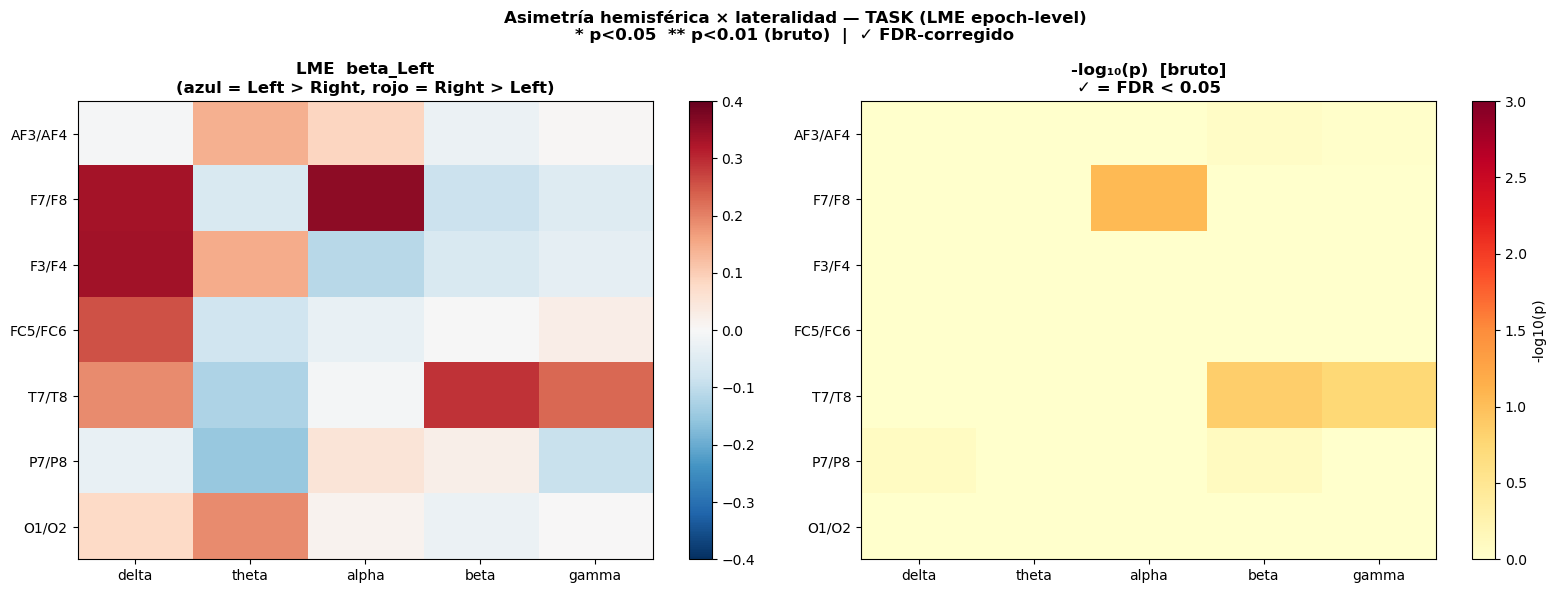

In [13]:
  # ============================================================
  # CELL LAT-6: Asimetría hemisférica sistemática — todos los
  # pares de canales × todas las bandas — durante TASK
  #
  # FAA solo miraba alpha en canales frontales. La lateralidad
  # es fundamentalmente motora: T7/T8 y FC5/FC6 en beta son
  # las hipótesis más fuertes en literatura.
  #
  # Pipeline:
  #   1. epoch_asym_all(): asimetría log(R)-log(L) por epoch,
  #      para los 7 pares × 5 bandas = 35 features
  #   2. LME por feature: asym ~ C(handedness) + (1|subject)
  #   3. Corrección FDR (Benjamini-Hochberg)
  #   4. Heatmap: beta (dirección) y -log10(p)
  #
  # Requiere: LAT-3 ejecutado (EPOCH_SAMP, STEP, EEG_CHANNELS)
  # ============================================================

  from statsmodels.formula.api import mixedlm
  from statsmodels.stats.multitest import multipletests
  import warnings
  warnings.filterwarnings('ignore')

  BANDS_ALL = {
      'delta': (1,  4),
      'theta': (4,  8),
      'alpha': (8,  13),
      'beta':  (13, 30),
      'gamma': (30, 45),
  }

  ALL_PAIRS = [
      ('AF3', 'AF4'),
      ('F7',  'F8'),
      ('F3',  'F4'),
      ('FC5', 'FC6'),
      ('T7',  'T8'),
      ('P7',  'P8'),
      ('O1',  'O2'),
  ]

  def epoch_asym_all(segment, pairs=ALL_PAIRS, bands=BANDS_ALL, sfreq=SFREQ):
      """log(R) - log(L) per epoch, all pairs × bands. PSD computed once per channel."""
      from scipy.signal import welch as _welch
      n = segment.shape[1]
      keys = [f'{l}_{r}_{b}' for l, r in pairs for b in bands]
      result = {k: [] for k in keys}

      start = 0
      while start + EPOCH_SAMP <= n:
          epoch = segment[:, start:start + EPOCH_SAMP]

          # compute PSD once per channel
          ch_psd = {}
          for ch in set(c for pair in pairs for c in pair):
              idx = EEG_CHANNELS.index(ch)
              f, psd = _welch(epoch[idx], fs=sfreq, nperseg=min(256, epoch.shape[1]))
              ch_psd[ch] = (f, psd)

          for l, r in pairs:
              f_l, psd_l = ch_psd[l]
              f_r, psd_r = ch_psd[r]
              for bname, (fmin, fmax) in bands.items():
                  mask = (f_l >= fmin) & (f_l < fmax)
                  pL = psd_l[mask].mean()
                  pR = psd_r[mask].mean()
                  result[f'{l}_{r}_{bname}'].append(
                      np.log(pR + 1e-12) - np.log(pL + 1e-12))
          start += STEP
      return {k: np.array(v) for k, v in result.items()}


  # -- 1. Dataframe epoch-level para TASK ---------------------------------------
  print("Building TASK epoch dataframe (35 features × todos los sujetos)...")
  print("  Puede tardar 1-2 min...\n")

  rows = []
  for _, row in coh_df.iterrows():
      sid  = row['subject_id']
      hand = row['handedness']
      if hand == 'Ambidextrous':
          continue
      try:
          segs = extract_condition_segments(find_edf(sid, session='G10'))
          seg  = segs.get('TASK')
          if seg is None or seg.shape[1] < EPOCH_SAMP:
              continue
          asym = epoch_asym_all(seg)
          n_ep = len(next(iter(asym.values())))
          for ep_idx in range(n_ep):
              r = {'subject_id': sid, 'handedness': hand}
              for k, vals in asym.items():
                  r[k] = vals[ep_idx]
              rows.append(r)
      except Exception as e:
          print(f"  {sid}: ERROR {e}")

  asym_df = pd.DataFrame(rows)
  print(f"  Epochs totales: {len(asym_df)}")
  print(f"  Zurdos: {asym_df[asym_df['handedness']=='Left']['subject_id'].nunique()} sujetos, "
        f"{(asym_df['handedness']=='Left').sum()} epochs")

  # -- 2. LME por feature -------------------------------------------------------
  print("\nAjustando LME para cada par × banda (35 modelos)...")

  COEF    = "C(handedness, Treatment('Right'))[T.Left]"
  feat_cols = [c for c in asym_df.columns if c not in ('subject_id', 'handedness')]
  lme_rows  = []

  for feat in feat_cols:
      df_f = asym_df[['subject_id', 'handedness', feat]].rename(columns={feat: 'asym'})
      try:
          model  = mixedlm("asym ~ C(handedness, Treatment('Right'))",
                           df_f, groups=df_f['subject_id'])
          result = model.fit(reml=True, method='lbfgs', disp=False)
          beta   = result.params.get(COEF, np.nan)
          se     = result.bse.get(COEF, np.nan)
          p      = result.pvalues.get(COEF, np.nan)
      except:
          beta, se, p = np.nan, np.nan, np.nan
      lme_rows.append({'feature': feat, 'beta': beta, 'se': se, 'p': p})

  res_df = pd.DataFrame(lme_rows)
  valid  = res_df.dropna(subset=['p'])

  # FDR correction
  _, p_fdr, _, _ = multipletests(valid['p'], method='fdr_bh')
  valid = valid.copy()
  valid['p_fdr'] = p_fdr

  # Parse feature name: "T7_T8_beta" → pair="T7/T8", band="beta"
  valid[['lch', 'rch', 'band']] = valid['feature'].str.rsplit('_', n=1, expand=False).apply(
      lambda x: pd.Series({'lch': x[0].split('_')[0],
                           'rch': x[0].split('_')[1],
                           'band': x[1]}))
  valid['pair'] = valid['lch'] + '/' + valid['rch']

  print("\n=== Top 10 por p-valor bruto ===")
  top = valid.sort_values('p')[['pair', 'band', 'beta', 'p', 'p_fdr']].head(10)
  print(top.to_string(index=False))

  # -- 3. Heatmaps --------------------------------------------------------------
  pair_order = [f'{l}/{r}' for l, r in ALL_PAIRS]
  band_order = list(BANDS_ALL.keys())

  beta_mat  = np.full((len(pair_order), len(band_order)), np.nan)
  p_mat     = np.full((len(pair_order), len(band_order)), np.nan)
  pfdr_mat  = np.full((len(pair_order), len(band_order)), np.nan)

  for _, r in valid.iterrows():
      i = pair_order.index(r['pair'])
      j = band_order.index(r['band'])
      beta_mat[i, j]  = r['beta']
      p_mat[i, j]     = r['p']
      pfdr_mat[i, j]  = r['p_fdr']

  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  # Panel izquierdo: beta (dirección del efecto)
  im1 = axes[0].imshow(beta_mat, cmap='RdBu_r', vmin=-0.4, vmax=0.4, aspect='auto')
  axes[0].set_xticks(range(len(band_order))); axes[0].set_xticklabels(band_order)
  axes[0].set_yticks(range(len(pair_order))); axes[0].set_yticklabels(pair_order)
  axes[0].set_title('LME  beta_Left\n(azul = Left > Right, rojo = Right > Left)',
                    fontweight='bold')
  plt.colorbar(im1, ax=axes[0])
  for i in range(len(pair_order)):
      for j in range(len(band_order)):
          p_raw = p_mat[i, j]
          if not np.isnan(p_raw):
              sig = '**' if p_raw < 0.01 else ('*' if p_raw < 0.05 else '')
              if sig:
                  axes[0].text(j, i, sig, ha='center', va='center',
                               fontsize=13, color='k', fontweight='bold')

  # Panel derecho: -log10(p)
  nlp = -np.log10(np.where(np.isnan(p_mat), 1.0, p_mat))
  im2 = axes[1].imshow(nlp, cmap='YlOrRd', vmin=0, vmax=3, aspect='auto')
  axes[1].set_xticks(range(len(band_order))); axes[1].set_xticklabels(band_order)
  axes[1].set_yticks(range(len(pair_order))); axes[1].set_yticklabels(pair_order)
  axes[1].set_title('-log₁₀(p)  [bruto]\n✓ = FDR < 0.05', fontweight='bold')
  plt.colorbar(im2, ax=axes[1], label='-log10(p)')
  # Línea p = 0.05
  axes[1].contour(nlp, levels=[-np.log10(0.05)], colors='white', linewidths=1.5)
  # Marcar FDR significativos
  for i in range(len(pair_order)):
      for j in range(len(band_order)):
          if not np.isnan(pfdr_mat[i, j]) and pfdr_mat[i, j] < 0.05:
              axes[1].text(j, i, '✓', ha='center', va='center',
                           fontsize=12, color='blue', fontweight='bold')

  plt.suptitle('Asimetría hemisférica × lateralidad — TASK (LME epoch-level)\n'
               '* p<0.05  ** p<0.01 (bruto)  |  ✓ FDR-corregido',
               fontsize=12, fontweight='bold')
  plt.tight_layout()
  plt.show()

Extrayendo IAF, EXP, TAR por sujeto (condición REC)...
  Sujetos: 49  |  Nuevas features: 42
  Dataset combinado: 49 sujetos × 151 columnas

=== SVR-RBF — Leave-One-Out CV ===

  Feature set               n_feat   MAE (yr)    vs Dummy
  -------------------------------------------------------
  Dummy (predict mean)           –       8.40           –
  PSD + Asymmetry              105       7.61      -0.79  *** MEJOR
  IAF only                      14       7.73      -0.68  *** MEJOR
  EXP (1/f) only                14       8.14      -0.26  *** MEJOR
  TAR only                      14       8.26      -0.14  *** MEJOR
  New features only             42       7.83      -0.57  *** MEJOR
  ALL features                 147       7.78      -0.62  *** MEJOR

  Mejor: 'PSD + Asymmetry'  MAE = 7.61 yr


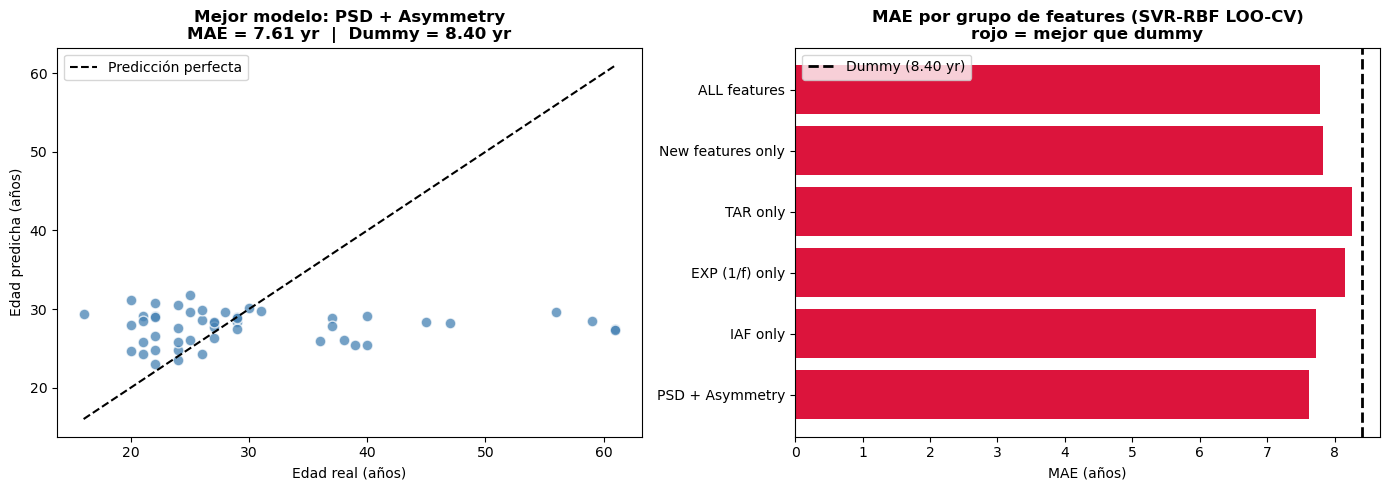

In [14]:
  # ============================================================
  # CELL AGE-1: Nuevas features espectrales + SVR-RBF LOO-CV
  #
  # Features nuevas (condición REC, por canal × 14 canales):
  #   - IAF: Individual Alpha Frequency (pico en 8-13 Hz)
  #   - EXP: exponente aperiódico 1/f (pendiente log-log 2-30 Hz)
  #   - TAR: Theta/Alpha Ratio
  #
  # Evaluación: SVR-RBF con Leave-One-Out CV
  # Comparativa entre grupos de features
  # ============================================================

  import pandas as pd
  import numpy as np
  from scipy.signal import welch
  from sklearn.svm import SVR
  from sklearn.preprocessing import StandardScaler
  from sklearn.model_selection import LeaveOneOut
  from sklearn.metrics import mean_absolute_error
  import warnings
  warnings.filterwarnings('ignore')

  # -- 1. Extraer nuevas features por sujeto (REC) ------------------------------
  def compute_spectral_extras(segment, sfreq=SFREQ):
      feats = {}
      for ch in EEG_CHANNELS:
          idx = EEG_CHANNELS.index(ch)
          f, psd = welch(segment[idx], fs=sfreq, nperseg=min(256, segment.shape[1]))

          # IAF: pico dentro de 8-13 Hz
          m_alpha = (f >= 8) & (f <= 13)
          feats[f'iaf_{ch}'] = float(f[m_alpha][np.argmax(psd[m_alpha])]) \
                               if m_alpha.sum() > 0 else 10.0

          # EXP: pendiente log10(PSD) ~ log10(freq) en 2-30 Hz
          m_fit = (f >= 2) & (f <= 30)
          if m_fit.sum() > 2:
              coeffs = np.polyfit(np.log10(f[m_fit]), np.log10(psd[m_fit] + 1e-30), 1)
              feats[f'exp_{ch}'] = float(coeffs[0])
          else:
              feats[f'exp_{ch}'] = np.nan

          # TAR: theta / alpha ratio
          p_theta = psd[(f >= 4) & (f < 8)].mean()
          p_alpha = psd[(f >= 8) & (f < 13)].mean()
          feats[f'tar_{ch}'] = float(p_theta / (p_alpha + 1e-30))

      return feats


  print("Extrayendo IAF, EXP, TAR por sujeto (condición REC)...")
  extra_rows = []
  for _, row in coh_df.iterrows():
      sid = row['subject_id']
      try:
          segs = extract_condition_segments(find_edf(sid, session='G10'))
          seg  = segs.get('REC')
          if seg is None:
              print(f"  {sid}: sin REC")
              continue
          feats = compute_spectral_extras(seg)
          feats['subject_id'] = sid
          extra_rows.append(feats)
      except Exception as e:
          print(f"  {sid}: ERROR {e}")

  extra_df = pd.DataFrame(extra_rows)
  print(f"  Sujetos: {len(extra_df)}  |  Nuevas features: {len(extra_df.columns) - 1}")

  # -- 2. Combinar con features existentes --------------------------------------
  base_df  = pd.read_csv(r'C:\Users\Laura\OneDrive\Escritorio\TFM_part1\eeg_features_biomex.csv')
  combined = base_df.merge(extra_df, on='subject_id', how='inner')
  y        = combined['age'].values
  print(f"  Dataset combinado: {combined.shape[0]} sujetos × {combined.shape[1]} columnas")

  exclude  = {'subject_id', 'sex', 'age', 'handedness', 'age_group'}
  psd_cols = [c for c in base_df.columns
              if c.startswith(('delta_','theta_','alpha_','beta_','gamma_'))]
  asy_cols = [c for c in base_df.columns if c not in exclude and c not in psd_cols]
  iaf_cols = [c for c in combined.columns if c.startswith('iaf_')]
  exp_cols = [c for c in combined.columns if c.startswith('exp_')]
  tar_cols = [c for c in combined.columns if c.startswith('tar_')]
  new_cols = iaf_cols + exp_cols + tar_cols
  all_cols = [c for c in combined.columns if c not in exclude]

  feature_groups = {
      'PSD only (baseline)': psd_cols,
      'PSD + Asymmetry':     psd_cols + asy_cols,
      'IAF only':            iaf_cols,
      'EXP (1/f) only':     exp_cols,
      'TAR only':            tar_cols,
      'New features only':   new_cols,
      'ALL features':        all_cols,
  }

  # -- 3. LOO-CV con SVR-RBF para cada grupo ------------------------------------
  print("\n=== SVR-RBF — Leave-One-Out CV ===\n")

  dummy_mae = np.mean(np.abs(y - y.mean()))
  print(f"  {'Feature set':<24}  {'n_feat':>6}  {'MAE (yr)':>9}  {'vs Dummy':>10}")
  print("  " + "-" * 55)
  print(f"  {'Dummy (predict mean)':<24}  {'–':>6}  {dummy_mae:>9.2f}  {'–':>10}")

  loo     = LeaveOneOut()
  results = {}

  def run_loo(X_raw, y):
      X = X_raw.copy().astype(float)
      col_means = np.nanmean(X, axis=0)
      for i, j in zip(*np.where(np.isnan(X))):
          X[i, j] = col_means[j]
      preds = np.zeros(len(y))
      for tr, te in loo.split(X):
          sc = StandardScaler()
          Xtr = sc.fit_transform(X[tr])
          Xte = sc.transform(X[te])
          svr = SVR(kernel='rbf', C=10, epsilon=1.0)
          svr.fit(Xtr, y[tr])
          preds[te] = svr.predict(Xte)
      return preds

  for gname, gcols in feature_groups.items():
      cols = [c for c in gcols if c in combined.columns]
      if not cols:
          continue
      preds = run_loo(combined[cols].values, y)
      mae   = mean_absolute_error(y, preds)
      diff  = mae - dummy_mae
      flag  = '  *** MEJOR' if mae < dummy_mae else ''
      results[gname] = {'mae': mae, 'preds': preds, 'n_feat': len(cols)}
      print(f"  {gname:<24}  {len(cols):>6}  {mae:>9.2f}  {diff:>+9.2f}{flag}")

  # -- 4. Scatter + barplot del mejor modelo ------------------------------------
  best_name = min(results, key=lambda k: results[k]['mae'])
  best      = results[best_name]
  print(f"\n  Mejor: '{best_name}'  MAE = {best['mae']:.2f} yr")

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Scatter predicted vs real
  ax = axes[0]
  ax.scatter(y, best['preds'], alpha=0.75, color='steelblue', edgecolors='white', s=60)
  mn, mx = min(y.min(), best['preds'].min()), max(y.max(), best['preds'].max())
  ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Predicción perfecta')
  ax.set_xlabel('Edad real (años)')
  ax.set_ylabel('Edad predicha (años)')
  ax.set_title(f"Mejor modelo: {best_name}\nMAE = {best['mae']:.2f} yr  |  "
               f"Dummy = {dummy_mae:.2f} yr", fontweight='bold')
  ax.legend()

  # Barplot MAE por grupo
  ax2  = axes[1]
  names = list(results.keys())
  maes  = [results[n]['mae'] for n in names]
  cols_bar = ['crimson' if m < dummy_mae else 'steelblue' for m in maes]
  ax2.barh(names, maes, color=cols_bar)
  ax2.axvline(dummy_mae, color='k', lw=2, ls='--', label=f'Dummy ({dummy_mae:.2f} yr)')
  ax2.set_xlabel('MAE (años)')
  ax2.set_title('MAE por grupo de features (SVR-RBF LOO-CV)\n'
                'rojo = mejor que dummy', fontweight='bold')
  ax2.legend()

  plt.tight_layout()
  plt.show()

PARTE A: Feature selection — correlación Spearman con edad

Top 15 features más correlacionadas con edad:
  Feature                          rho         p
  ----------------------------------------------
  O2_gamma                      -0.470    0.0007 *
  T8_gamma                      -0.447    0.0013 *
  iaf_P8                        -0.432    0.0019 *
  P8_gamma                      -0.417    0.0029 *
  asym_F3_F4_theta              +0.392    0.0054 *
  T8_beta                       -0.387    0.0060 *
  O1_gamma                      -0.370    0.0088 *
  T7_gamma                      -0.358    0.0115 *
  P7_gamma                      -0.342    0.0162 *
  T7_beta                       -0.328    0.0215 *
  iaf_F3                        -0.325    0.0225 *
  tar_F7                        -0.316    0.0270 *
  T7_delta                      +0.311    0.0295 *
  exp_T7                        -0.291    0.0427 *
  asym_F3_F4_alpha              +0.287    0.0452 *

SVR-RBF LOO-CV con top-K featu

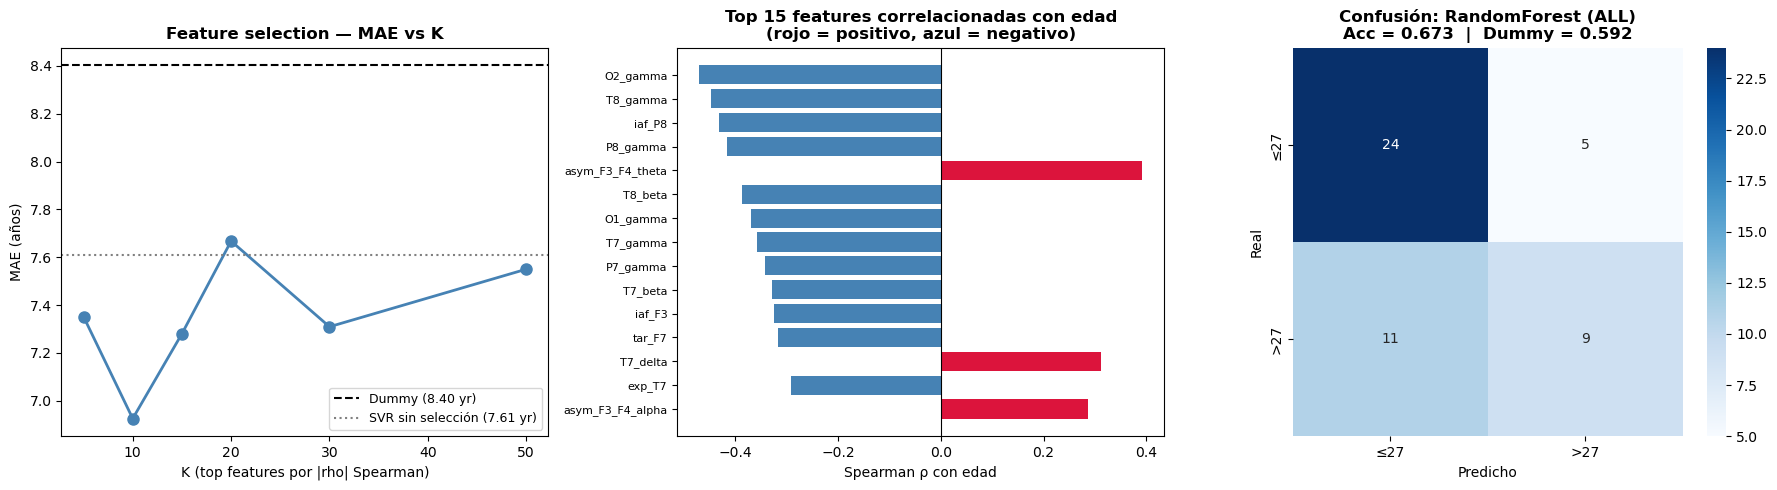


Classification report — RandomForest (ALL):
              precision    recall  f1-score   support

 Young (≤27)       0.69      0.83      0.75        29
 Older (>27)       0.64      0.45      0.53        20

    accuracy                           0.67        49
   macro avg       0.66      0.64      0.64        49
weighted avg       0.67      0.67      0.66        49



In [16]:
  # ============================================================
  # CELL AGE-2: Feature selection + Clasificación binaria
  #
  # Parte A: top-K features por correlación Spearman con edad
  #          → SVR-RBF LOO-CV para K = 5, 10, 15, 20, 30, 50
  #
  # Parte B: clasificación binaria Young (≤27) vs Older (>27)
  #          → SVC-RBF y RandomForest con LOO-CV
  # ============================================================

  from scipy.stats import spearmanr
  from sklearn.svm import SVC
  from sklearn.ensemble import RandomForestClassifier
  from sklearn.metrics import (accuracy_score, confusion_matrix,
                               classification_report, mean_absolute_error)
  try:
      import seaborn as sns
      HAS_SNS = True
  except ImportError:
      HAS_SNS = False

  # Features y target (de AGE-1)
  all_feat_cols = [c for c in combined.columns
                   if c not in {'subject_id', 'sex', 'age', 'handedness', 'age_group'}]
  X_all = combined[all_feat_cols].values.astype(float)
  col_means = np.nanmean(X_all, axis=0)
  for i, j in zip(*np.where(np.isnan(X_all))):
      X_all[i, j] = col_means[j]

  y        = combined['age'].values
  dummy_mae = np.mean(np.abs(y - y.mean()))

  # ============================================================
  # PARTE A — Feature selection por |rho| de Spearman
  # ============================================================
  print("=" * 58)
  print("PARTE A: Feature selection — correlación Spearman con edad")
  print("=" * 58)

  rhos = []
  for j, col in enumerate(all_feat_cols):
      rho, p = spearmanr(X_all[:, j], y)
      rhos.append({'feature': col, 'rho': rho, 'abs_rho': abs(rho), 'p': p})
  rho_df = pd.DataFrame(rhos).sort_values('abs_rho', ascending=False).reset_index(drop=True)

  print("\nTop 15 features más correlacionadas con edad:")
  print(f"  {'Feature':<26}  {'rho':>8}  {'p':>8}")
  print("  " + "-" * 46)
  for _, r in rho_df.head(15).iterrows():
      star = '*' if r['p'] < 0.05 else ''
      print(f"  {r['feature']:<26}  {r['rho']:>+8.3f}  {r['p']:>8.4f} {star}")

  print("\nSVR-RBF LOO-CV con top-K features:")
  print(f"  {'K':>4}  {'MAE (yr)':>9}  {'vs Dummy':>10}")
  print("  " + "-" * 28)

  k_maes = {}
  best_k_mae, best_k, best_k_preds = 999, None, None

  for K in [5, 10, 15, 20, 30, 50]:
      top_idx = [all_feat_cols.index(c) for c in rho_df.head(K)['feature']]
      preds   = run_loo(X_all[:, top_idx], y)
      mae     = mean_absolute_error(y, preds)
      k_maes[K] = mae
      flag    = '  *** MEJOR' if mae < dummy_mae else ''
      if mae < best_k_mae:
          best_k_mae, best_k, best_k_preds = mae, K, preds.copy()
      print(f"  {K:>4}  {mae:>9.2f}  {mae - dummy_mae:>+9.2f}{flag}")

  prev_mae = 7.61
  print(f"\n  Mejor K = {best_k}  MAE = {best_k_mae:.2f} yr  "
        f"(SVR sin selección: {prev_mae:.2f} yr)")

  # ============================================================
  # PARTE B — Clasificación binaria de edad
  # ============================================================
  print("\n" + "=" * 58)
  print("PARTE B: Clasificación binaria — Young (≤27) vs Older (>27)")
  print("=" * 58)

  THRESHOLD = 27
  y_bin     = (y > THRESHOLD).astype(int)
  n_young   = (y_bin == 0).sum()
  n_older   = (y_bin == 1).sum()
  dummy_acc = max(n_young, n_older) / len(y_bin)

  print(f"\n  Young (≤{THRESHOLD}): {n_young}  |  Older (>{THRESHOLD}): {n_older}")
  print(f"  Dummy accuracy (mayoría): {dummy_acc:.3f}\n")
  print(f"  {'Classifier':<26}  {'Accuracy':>9}  {'vs Dummy':>10}")
  print("  " + "-" * 50)
  print(f"  {'Dummy (majority)':<26}  {dummy_acc:>9.3f}  {'–':>10}")

  top20_idx = [all_feat_cols.index(c) for c in rho_df.head(20)['feature']]
  classifiers = {
      'SVC-RBF (ALL)':      (SVC(kernel='rbf', C=10, gamma='scale'),  X_all),
      'SVC-RBF (top-20)':   (SVC(kernel='rbf', C=10, gamma='scale'),  X_all[:, top20_idx]),
      'RandomForest (ALL)': (RandomForestClassifier(n_estimators=200, random_state=42), X_all),
  }

  clf_results = {}
  for cname, (clf, X_c) in classifiers.items():
      y_pred = np.zeros(len(y_bin), dtype=int)
      for tr, te in loo.split(X_c):
          sc  = StandardScaler()
          Xtr = sc.fit_transform(X_c[tr])
          Xte = sc.transform(X_c[te])
          clf.fit(Xtr, y_bin[tr])
          y_pred[te] = clf.predict(Xte)
      acc  = accuracy_score(y_bin, y_pred)
      flag = '  *** MEJOR' if acc > dummy_acc else ''
      clf_results[cname] = {'acc': acc, 'preds': y_pred}
      print(f"  {cname:<26}  {acc:>9.3f}  {acc - dummy_acc:>+9.3f}{flag}")

  best_clf     = max(clf_results, key=lambda k: clf_results[k]['acc'])
  best_clf_res = clf_results[best_clf]

  # -- Plots -------------------------------------------------------------------
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))

  # A1: MAE vs K
  ax = axes[0]
  ax.plot(list(k_maes.keys()), list(k_maes.values()), 'o-', color='steelblue', lw=2, ms=8)
  ax.axhline(dummy_mae, color='k',    ls='--', lw=1.5, label=f'Dummy ({dummy_mae:.2f} yr)')
  ax.axhline(prev_mae,  color='gray', ls=':',  lw=1.5, label=f'SVR sin selección ({prev_mae:.2f} yr)')
  ax.set_xlabel('K (top features por |rho| Spearman)')
  ax.set_ylabel('MAE (años)')
  ax.set_title('Feature selection — MAE vs K', fontweight='bold')
  ax.legend(fontsize=9)

  # A2: Top-15 features barplot
  ax2   = axes[1]
  top15 = rho_df.head(15)
  cols_bar = ['crimson' if r > 0 else 'steelblue' for r in top15['rho']]
  ax2.barh(top15['feature'][::-1], top15['rho'][::-1], color=cols_bar[::-1])
  ax2.axvline(0, color='k', lw=0.8)
  ax2.set_xlabel('Spearman ρ con edad')
  ax2.set_title('Top 15 features correlacionadas con edad\n(rojo = positivo, azul = negativo)',
                fontweight='bold')
  ax2.tick_params(axis='y', labelsize=8)

  # B1: Confusion matrix
  ax3 = axes[2]
  cm  = confusion_matrix(y_bin, best_clf_res['preds'])
  if HAS_SNS:
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
                  xticklabels=[f'≤{THRESHOLD}', f'>{THRESHOLD}'],
                  yticklabels=[f'≤{THRESHOLD}', f'>{THRESHOLD}'])
  else:
      im = ax3.imshow(cm, cmap='Blues')
      for (i2, j2), v in np.ndenumerate(cm):
          ax3.text(j2, i2, str(v), ha='center', va='center', fontsize=14)
      ax3.set_xticks([0,1]); ax3.set_xticklabels([f'≤{THRESHOLD}', f'>{THRESHOLD}'])
      ax3.set_yticks([0,1]); ax3.set_yticklabels([f'≤{THRESHOLD}', f'>{THRESHOLD}'])
  ax3.set_xlabel('Predicho'); ax3.set_ylabel('Real')
  ax3.set_title(f'Confusión: {best_clf}\nAcc = {best_clf_res["acc"]:.3f}  |  Dummy = {dummy_acc:.3f}',
                fontweight='bold')

  plt.tight_layout()
  plt.show()

  print(f"\nClassification report — {best_clf}:")
  print(classification_report(y_bin, best_clf_res['preds'],
                               target_names=[f'Young (≤{THRESHOLD})', f'Older (>{THRESHOLD})']))

In [17]:
  # AGE-2b: RandomForest con class_weight='balanced'
  from sklearn.metrics import classification_report, accuracy_score

  rf_bal = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
  y_pred_bal = np.zeros(len(y_bin), dtype=int)

  for tr, te in loo.split(X_all):
      sc  = StandardScaler()
      Xtr = sc.fit_transform(X_all[tr])
      Xte = sc.transform(X_all[te])
      rf_bal.fit(Xtr, y_bin[tr])
      y_pred_bal[te] = rf_bal.predict(Xte)

  acc_bal = accuracy_score(y_bin, y_pred_bal)
  print(f"RandomForest balanced  —  Acc = {acc_bal:.3f}  (antes: 0.673, dummy: {dummy_acc:.3f})\n")
  print(classification_report(y_bin, y_pred_bal,
        target_names=[f'Young (≤{THRESHOLD})', f'Older (>{THRESHOLD})']))

RandomForest balanced  —  Acc = 0.653  (antes: 0.673, dummy: 0.592)

              precision    recall  f1-score   support

 Young (≤27)       0.68      0.79      0.73        29
 Older (>27)       0.60      0.45      0.51        20

    accuracy                           0.65        49
   macro avg       0.64      0.62      0.62        49
weighted avg       0.65      0.65      0.64        49

